![Google Play Store Analysis](public/google-play-logo.png)

# Google Play Store App Trend Analysis
**Course:** Data Science Course: Cloud Computing  
**Author:** Moses Pierre
**Date:** May 2026  

## Overview
This notebook analyzes trends in Google Play Store app success on behalf of a startup 
looking to enter the Android app market. Following the CRISP-DM process, I load and 
explore the raw dataset using PySpark, identify and resolve data quality issues, produce 
cleaned data for visualization. Addition, I developed a couple of demo charts to test cleaned data.

**Key Finding:** The Family and Game categories dominate in both app volume and total 
installs, while free apps significantly outperform paid apps in reach. Categories like 
Events and Education lead in average user ratings, suggesting quality over quantity 
opportunities for a new entrant.

## Business Understanding
**Scenario:** A startup wants to break into the Android/Google Play Store market. 
As the data analyst on the team, the goal is to identify trends in app success — 
including which categories are competitive, what drives installs, and how pricing 
and app characteristics relate to user ratings.

**Stakeholders:** Startup founders, product team, app developers

**Why this matters:** Entering a crowded market without data-driven direction risks 
wasted development resources. Understanding category saturation, install patterns, 
and rating drivers helps the team make informed decisions about what type of app 
to build and how to position it.

## Business Questions
| # | Question | Purpose |
|---|---|---|
| Q1 | Which app categories are most saturated? | Identify competitive landscape |
| Q2 | Which categories have the highest average ratings? | Find quality benchmarks |
| Q3 | Do free apps get more installs than paid apps? | Inform monetization strategy |
| Q4 | Which categories lead total installs? | Identify high-reach markets |
| Q5 | How does app size affect ratings or installs? | Inform technical decisions |
| Q6 | What content ratings are most common in top-performing apps? | Guide audience targeting |
| Q7 | What is the relationship between price and installs or success? | Inform pricing strategy |

## Data Understanding (Initial EDA)

## Column Inventory
| Column | Raw Type | Description |
|---|---|---|
| App | String | App name |
| Category | String | Store category |
| Rating | Float | Average user rating |
| Reviews | String/Int | Number of user reviews |
| Size | String | App size |
| Installs | String | Install count range |
| Type | String | Free or Paid |
| Price | String/Float | App price |
| Content Rating | String | Audience rating |
| Genres | String | Sub-genre tags |
| Last Updated | String | Date of last update |
| Current Ver | String | Current version string |
| Android Ver | String | Minimum Android version required |

The EDA below checks row/column counts, schema, null counts, unique categorical values, 
rating distribution, and samples of the known messy columns (Installs, Size, Price).

In [103]:
# Imports
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import FloatType, LongType
import pandas as pd
import matplotlib.pyplot as plt


# Start Spark session
spark = SparkSession.builder \
    .appName("GooglePlayStoreAnalysis") \
    .getOrCreate()

# Load data
df = spark.read.csv("google_play_store_dataset.csv", header=True, inferSchema=True)

# Quick look
df.printSchema()
df.show(5,)
print(f"Total rows: {df.count()}")
print(f"Total columns: {len(df.columns)}")

root
 |-- App: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Rating: string (nullable = true)
 |-- Reviews: string (nullable = true)
 |-- Size: string (nullable = true)
 |-- Installs: string (nullable = true)
 |-- Type: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- Content Rating: string (nullable = true)
 |-- Genres: string (nullable = true)
 |-- Last Updated: string (nullable = true)
 |-- Current Ver: string (nullable = true)
 |-- Android Ver: string (nullable = true)

+--------------------+--------------+------+-------+----+-----------+----+-----+--------------+--------------------+----------------+------------------+------------+
|                 App|      Category|Rating|Reviews|Size|   Installs|Type|Price|Content Rating|              Genres|    Last Updated|       Current Ver| Android Ver|
+--------------------+--------------+------+-------+----+-----------+----+-----+--------------+--------------------+----------------+--------------

## EDA Findings & Observations

Running initial EDA revealed the following data quality issues that will require 
cleaning in Step 4:

| Issue | Column | Detail |
|---|---|---|
| Non-numeric strings | `Installs` | Values like "10,000+" need commas and "+" stripped |
| Non-numeric strings | `Price` | Values like "$4.99" need the dollar sign stripped |
| Mixed format strings | `Size` | Mix of "M" (MB), "k" (KB), and "Varies with device" |
| Invalid category value | `Type` | Contains "0" in addition to "Free" and "Paid" |
| Out-of-range values | `Rating` | Max value found was 19.0 which doesn't work on a 1–5 scale |
| Missing values | `Rating` | 1,474 null values |
| Missing values | `Type`, `Content Rating` | 1 null each |
| Duplicate rows | All columns | 483 fully duplicated rows |
| Wrong inferred types | `Rating`, `Reviews` | Read as string by inferSchema in some cases |

**Decision on Rating nulls:** Rows with null Ratings are dropped. 

## Prompt Used

You are an experienced data engineer familiar with PySpark. I am analyzing a Google Play Store dataset including: App, Category, Rating, Reviews, Size, Installs, Type, Price, Content Rating, Genres, Last Updated, Current Ver, and Android Ver.
Write PySpark code to perform initial EDA that checks: row and column counts, schema, null counts for all columns, unique values for categorical columns (Category, Type, Content Rating), a statistical summary of the Rating column, sample output of the messy columns (Installs, Size, Price), and a duplicate row count.


In [104]:
# EDA Code Here - Create New Cells As Needed

# 1. Row and column count
print(f"Rows: {df.count()}, Columns: {len(df.columns)}")

# 2. Schema
df.printSchema()

# 3. Null counts per column
print("Null counts:")
df.select([F.count(F.when(F.col(c).isNull() | (F.col(c) == ""), c))
           .alias(c) for c in df.columns]).show()

# 4. Unique values in categorical columns
for col in ["Category", "Type", "Content Rating"]:
    print(f"\nUnique values in '{col}':")
    df.select(col).distinct().show(50, truncate=False)

# 5. Rating distribution
print("Rating stats:")
df.select("Rating").summary().show()

# 6. Sample of messy columns
print("Sample of Installs, Size, Price columns:")
df.select("App", "Installs", "Size", "Price").show(10, truncate=False)

# 7. Duplicate check
dupes = df.count() - df.dropDuplicates().count()
print(f"Duplicate rows: {dupes}")

Rows: 10841, Columns: 13
root
 |-- App: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Rating: string (nullable = true)
 |-- Reviews: string (nullable = true)
 |-- Size: string (nullable = true)
 |-- Installs: string (nullable = true)
 |-- Type: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- Content Rating: string (nullable = true)
 |-- Genres: string (nullable = true)
 |-- Last Updated: string (nullable = true)
 |-- Current Ver: string (nullable = true)
 |-- Android Ver: string (nullable = true)

Null counts:
+---+--------+------+-------+----+--------+----+-----+--------------+------+------------+-----------+-----------+
|App|Category|Rating|Reviews|Size|Installs|Type|Price|Content Rating|Genres|Last Updated|Current Ver|Android Ver|
+---+--------+------+-------+----+--------+----+-----+--------------+------+------------+-----------+-----------+
|  0|       0|     0|      0|   0|       0|   0|    0|             1|     0|           0|          

# Data Preparation (Cleaning)

Based on the issues identified in Step 3, the following cleaning steps are applied 
in order. Each step is documented with the reasoning for the decision made.

## Cleaning Decisions Log

| Step | Column | Action | Reasoning |
|---|---|---|---|
| 1 | All | Drop 483 duplicate rows | Exact duplicates add no analytical value and skew counts |
| 2 | `Installs` | Strip `","` and `"+"`, cast to `LongType` | Required for numeric aggregation and comparison |
| 3 | `Price` | Strip `"$"`, cast to `FloatType` | Required to distinguish free vs. paid and analyze price ranges |
| 4 | `Size` | Parse "M"→MB float, "k"→KB÷1024 float, nullify "Varies with device" | Enables numeric size analysis; "Varies with device" has no fixed value |
| 5 | `Type` | Filter to only "Free" or "Paid" | The value "0" is a data entry error with no valid business meaning |
| 6 | `Rating` | Filter out values > 5.0 | Ratings above 5.0 are technically impossible and indicate corrupt data |
| 7 | Key columns | Drop rows with nulls in Rating, Category, Installs, Type, Content Rating | These columns are central to all 7 business questions |
| 8 | `Rating`, `Reviews` | Cast to `FloatType` and `LongType` | Correct types needed for Tableau aggregations and notebook charts |

**Output:** Cleaned dataset exported as `google_play_cleaned.csv` for use in Tableau.

## Prompts Used

### Initial
You are an experienced data engineer using PySpark. I have uploaded a Google Play Store dataset CSV file. Please read through the data, identify any data quality issues present, and write PySpark code to clean and resolve all issues you find. After cleaning, validate the results with null checks and row counts, then export the final cleaned dataset to a new CSV file using Pandas.

### Evolution after the first produced errors but atleast exposed the inpurities
You are an experienced data engineer familiar with PySpark. I have a Google Play Store dataset loaded as a PySpark DataFrame called df with columns: App, Category, Rating, Reviews, Size, Installs, Type, Price, Content Rating, Genres, Last Updated, Current Ver, Android Ver.
After running initial EDA, I found the following data quality issues that need to be cleaned:

Installs is a string with commas and "+" characters (e.g. "10,000+") — needs to be numeric
Price is a string with a "$" prefix (e.g. "$4.99") — needs to be a float
Size contains values like "19M", "4.2k", and "Varies with device" — needs to be converted to a consistent numeric MB float (nullify "Varies with device")
Type has an invalid value of "0" in addition to "Free" and "Paid"
Rating has values above 5.0 (max found: 19.0) which are invalid for a 1–5 scale
There are 483 duplicate rows
Nulls exist in: Rating, Type , Content Rating

Write PySpark code to clean all of these issues step by step, with comments. At the end, add a data validation check that confirms the cleaned DataFrame has no nulls in key columns, correct types, and valid Rating values. Name the final cleaned DataFrame df_final.

In [105]:
# ── 1. Drop duplicates ──────────────────────────────────────────
df_clean = df.dropDuplicates()
print(f"After dedup: {df_clean.count()} rows (removed {df.count() - df_clean.count()})")

# ── 2. Clean Installs: remove "," and "+" then cast to long ─────
df_clean = df_clean.withColumn(
    "Installs",
    F.regexp_replace(F.col("Installs"), "[,+]", "").cast(LongType())
)

# ── 3. Clean Price: remove "$" then cast to float ───────────────
df_clean = df_clean.withColumn(
    "Price",
    F.regexp_replace(F.col("Price"), "\\$", "").cast(FloatType())
)

# ── 4. Clean Size: convert M → float MB, k → float KB→MB,
#       set "Varies with device" to null ──────────────────────────
df_clean = df_clean.withColumn(
    "Size_MB",
    F.when(F.col("Size").endswith("M"),
           F.regexp_replace(F.col("Size"), "M", "").cast(FloatType()))
    .when(F.col("Size").endswith("k"),
           F.regexp_replace(F.col("Size"), "k", "").cast(FloatType()) / 1024)
    .otherwise(None)  # covers "Varies with device" and anything else
)

# ── 5. Fix Type column: drop row where Type = "0" or null ───────
df_clean = df_clean.filter(F.col("Type").isin(["Free", "Paid"]))

# ── 6. Filter invalid Ratings: keep only 1.0–5.0 ────────────────
df_clean = df_clean.filter(
    (F.col("Rating").isNull()) | ((F.col("Rating") >= 1.0) & (F.col("Rating") <= 5.0))
)

# ── 7. Drop rows with nulls in key analytical columns ───────────
df_final = df_clean.dropna(subset=["Rating", "Category", "Installs", "Type", "Content Rating"])

# ── 8. Cast remaining columns to correct numeric types ──────────
df_final = df_final.withColumn("Rating", F.col("Rating").cast(FloatType())) \
                   .withColumn("Reviews", F.col("Reviews").cast(LongType()))


print(f"Final cleaned rows: {df_final.count()}")
df_final.printSchema()
df_final.show(5, truncate=False)

# DATA VALIDATION
print("\n── Validation Checks ──")

# Check no nulls in key columns
key_cols = ["App", "Category", "Rating", "Installs", "Type", "Price", "Content Rating"]
null_check = df_final.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in key_cols
])
print("Null counts in key columns:")
null_check.show()

# Check Rating is within valid range
invalid_ratings = df_final.filter((F.col("Rating") < 1.0) | (F.col("Rating") > 5.0)).count()
print(f"Ratings out of 1–5 range: {invalid_ratings}")

# Check Type only contains valid values
print("Type distinct values after cleaning:")
df_final.select("Type").distinct().show()

# Check Installs is numeric (no nulls from bad parse)
print(f"Null Installs after clean: {df_final.filter(F.col('Installs').isNull()).count()}")

# Check Price is numeric
print(f"Null Price after clean: {df_final.filter(F.col('Price').isNull()).count()}")

After dedup: 10358 rows (removed 483)
Final cleaned rows: 8890
root
 |-- App: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Rating: float (nullable = true)
 |-- Reviews: long (nullable = true)
 |-- Size: string (nullable = true)
 |-- Installs: long (nullable = true)
 |-- Type: string (nullable = true)
 |-- Price: float (nullable = true)
 |-- Content Rating: string (nullable = true)
 |-- Genres: string (nullable = true)
 |-- Last Updated: string (nullable = true)
 |-- Current Ver: string (nullable = true)
 |-- Android Ver: string (nullable = true)
 |-- Size_MB: double (nullable = true)

+------------------------------+-----------------+------+-------+------------------+---------+----+-----+--------------+---------------+--------------+------------------+------------------+------------------+
|App                           |Category         |Rating|Reviews|Size              |Installs |Type|Price|Content Rating|Genres         |Last Updated  |Current Ver       |Andr

In [106]:
# Save cleaned data file for Tableau usage
df_pandas = df_final.toPandas()
df_pandas.to_csv("google_play_cleaned.csv", index=False)
spark.stop()

## Data Analysis

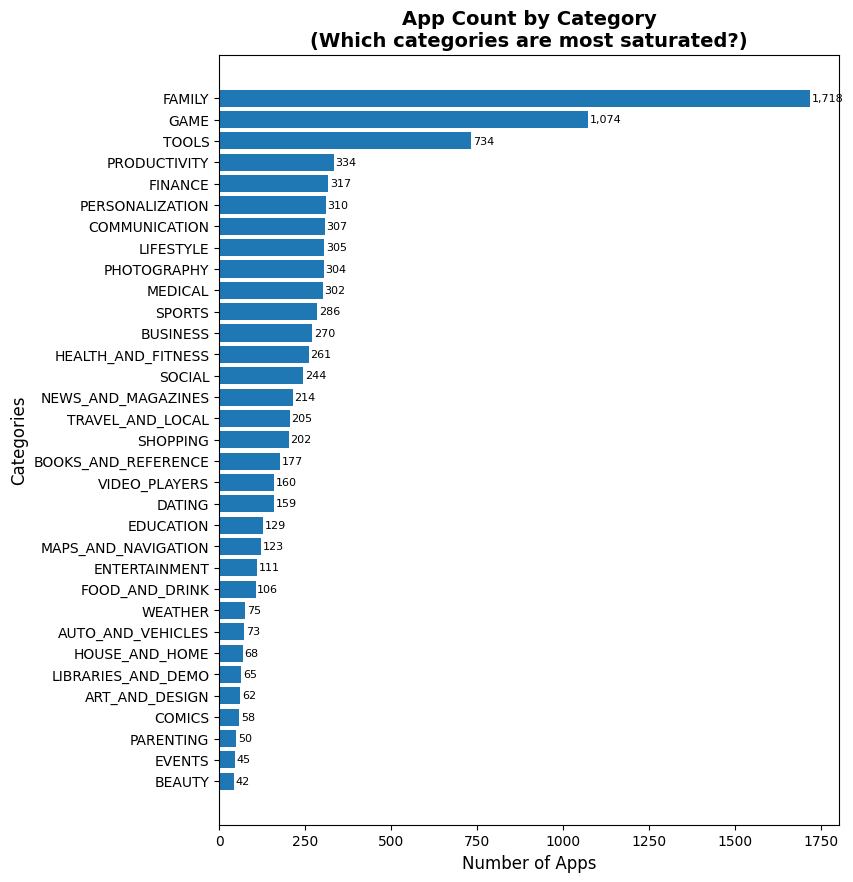

In [107]:
# Analysis Code Here - if needed
df_pandas = pd.read_csv("google_play_cleaned.csv")

# ── Chart 1: App Count by Category ──
category_counts = df_pandas['Category'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
bars = ax.barh(category_counts.index, category_counts.values)
ax.set_xlabel("Number of Apps", fontsize=12)
ax.set_ylabel("Categories",fontsize=12)
ax.set_title("App Count by Category\n(Which categories are most saturated?)", fontsize=14, fontweight='bold')


# Add value labels on bars
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width()):,}', va='center', fontsize=8)

plt.show()

### Chart 1 Observation — App Count by Category 
**Family** (1,718 apps) and **Game** (1,074 apps) are by far the most saturated categories, 
followed distantly by Tools (734). For a newcomer, these high-competition categories 
present a significant barrier. Middle-tier categories like Finance, Productivity, and 
Personalization (300–335 apps each) may offer better opportunity with less competition.

## Prompt Used 
Using the same cleaned Google Play Store Pandas DataFrame df_pandas, write matplotlib code to create a horizontal bar chart showing the average app rating per category, sorted from highest to lowest. Include a vertical dashed reference line at the overall average rating. Add a title, axis labels, and value annotations on each bar.

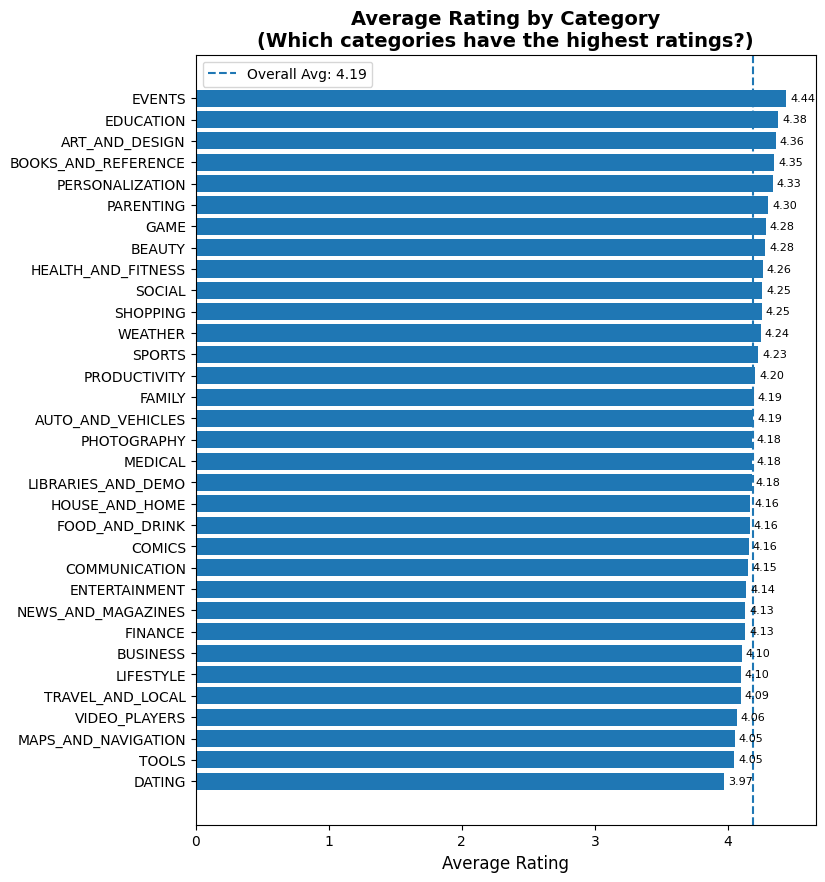

In [108]:
# ── Chart 2: Avg Rating by Category ──
avg_rating = df_pandas.groupby('Category')['Rating'].mean().sort_values()
overall_avg = df_pandas['Rating'].mean()

fig, ax = plt.subplots(figsize=(8, 10))
bars = ax.barh(avg_rating.index, avg_rating.values)
ax.axvline(overall_avg, linestyle='--', linewidth=1.5, label=f'Overall Avg: {overall_avg:.2f}')
ax.set_xlabel("Average Rating", fontsize=12)
ax.set_title("Average Rating by Category\n(Which categories have the highest ratings?)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

for bar in bars:
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.2f}', va='center', fontsize=8)

plt.show()

### Chart 2 Observation — Average Rating by Category 
The overall average rating across the cleaned dataset is **4.19**. Events (4.44) and 
Education (4.38) lead in average ratings, suggesting users in these categories are 
highly satisfied. Most categories cluster between 4.0 and 4.4, meaning the rating 
distribution is relatively tight. Small differences in quality can meaningfully 
differentiate an app within its category.

## Link to Published Dashboard
https://public.tableau.com/views/GooglePlayStoreAnalysis_17795816789220/Page1MarketLandscape?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

## Conclusion

### Summary of Findings
- **Q1 — Category Competition:** Family (1,718 apps) and Game (1,074) are 
  the most saturated categories — significant barriers for new entrants. 
  Mid-tier categories like Finance and Productivity (300-335 apps) offer 
  lower competition opportunities.

- **Q2 — Ratings by Category:** Overall average rating is 4.19. Events (4.44) 
  and Education (4.38) lead. Ratings are tightly clustered (3.97–4.44), 
  meaning small quality improvements can meaningfully differentiate an app.

- **Q3 — Free vs Paid:** Free apps have a median of 500,000 installs vs 
  5,000 for paid apps, a huge difference. Paid apps rate marginally higher 
  (4.26 vs 4.18) but reach far fewer users. Strong signal to launch free 
  with alternative monetization.

- **Q4 — Install Dominance:** Game dominates total installs (31.5B) despite 
  having fewer apps than Family. Communication and Social also punch above 
  their weight in installs relative to app count.

- **Q5 — App Size:** General upward trend. Larger apps (70MB) average 
  64.7M installs. Apps under 10MB average only 1.5M. Feature-rich apps 
  tend to perform better but require more development investment.

- **Q6 — Content Rating:** Everyone-rated apps average 31M installs, 
  Teen-rated average 30M. Adults only 18+ averages just 666K. Broad 
  audience targeting dramatically increases install potential.

- **Q7 — Price vs Installs:** Among paid apps, lower price points ($1-5) 
  generally yield more installs. The $13 bin shows an outlier spike. 
  Overall confirms that pricing above $5 significantly reduces reach.

### Limitations & Assumptions
- **Dataset age:** This dataset was scraped in 2018 and does not reflect the current Play Store landscape
- **Size_MB nulls:** 1,467 apps list "Varies with device" for size — these are null in `Size_MB` and excluded from size-related analysis
- **Installs are ranges:** The original install counts are bucketed (e.g. "10,000+"), not exact figures. The cleaned numeric value represents the lower bound of each range
- **Rating nulls dropped:** 1,474 rows with missing ratings were removed rather than imputed to preserve analytical integrity
- **No temporal analysis:** `Last Updated` was retained in the cleaned CSV but not deeply analyzed due to inconsistent date formatting